In [3]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")

한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [4]:
# 문제 1: 시간대별 주문량 추이를 분석하여 피크 타임을 찾고, 요일별로 패턴에 차이가 있는지 확인하세요
# 시각화: 히트맵

# 비즈니스 목적: 서버 리소스 할당, 인력 배치, 타임 세일 이벤트 기획 등 운영 최적화에 활용합니다

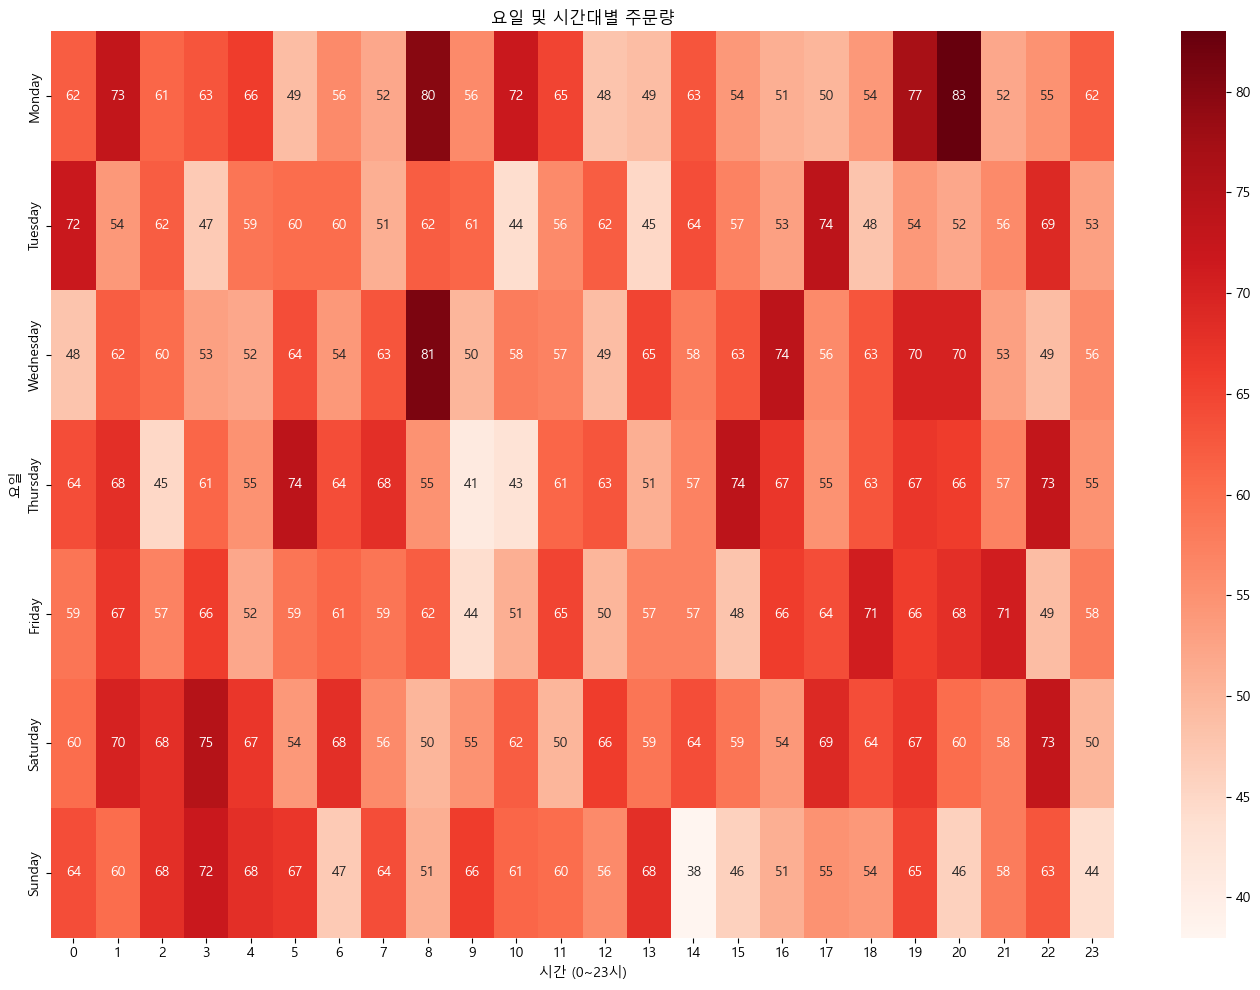

In [5]:
# 데이터 전처리
cols = ['customer_id','order_date']
df_data1 = df[cols].copy()

df_data1['weekday'] = df_data1['order_date'].dt.dayofweek

df_data1['times'] = df_data1['order_date'].dt.hour

time_cnt = df_data1.groupby(['times','weekday']).agg(cnt=('customer_id','count')).reset_index()

heatmap_data = time_cnt.pivot(index='weekday', columns='times', values='cnt')
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 히트맵 시각화
plt.figure(figsize=(14, 10))

sns.heatmap(heatmap_data, 
            annot=True,           # 숫자 표시
            cmap='Reds',        # 색상 팔레트
            )

# 축 레이블 설정
plt.ylabel('요일')
plt.xlabel('시간 (0~23시)')
plt.title('요일 및 시간대별 주문량')

# x축 요일 라벨 변경
plt.yticks(ticks=np.arange(7) + 0.5, labels=weekday_labels)

plt.tight_layout()
plt.show()

In [6]:
# 문제 2: 월별 주문 건수와 평균 주문액(AOV)의 변화 추이를 함께 시각화하여 분석하세요.
# 시각화: 이중 축 차트

# 비즈니스 목적: 비즈니스의 양적 성장(주문 건수)과 질적 성장(객단가)을 동시에 파악하여, 프로모션이 단순히 주문 수만 늘렸는지 아니면 신제 매출 기여도를 높였는지 평가합니다

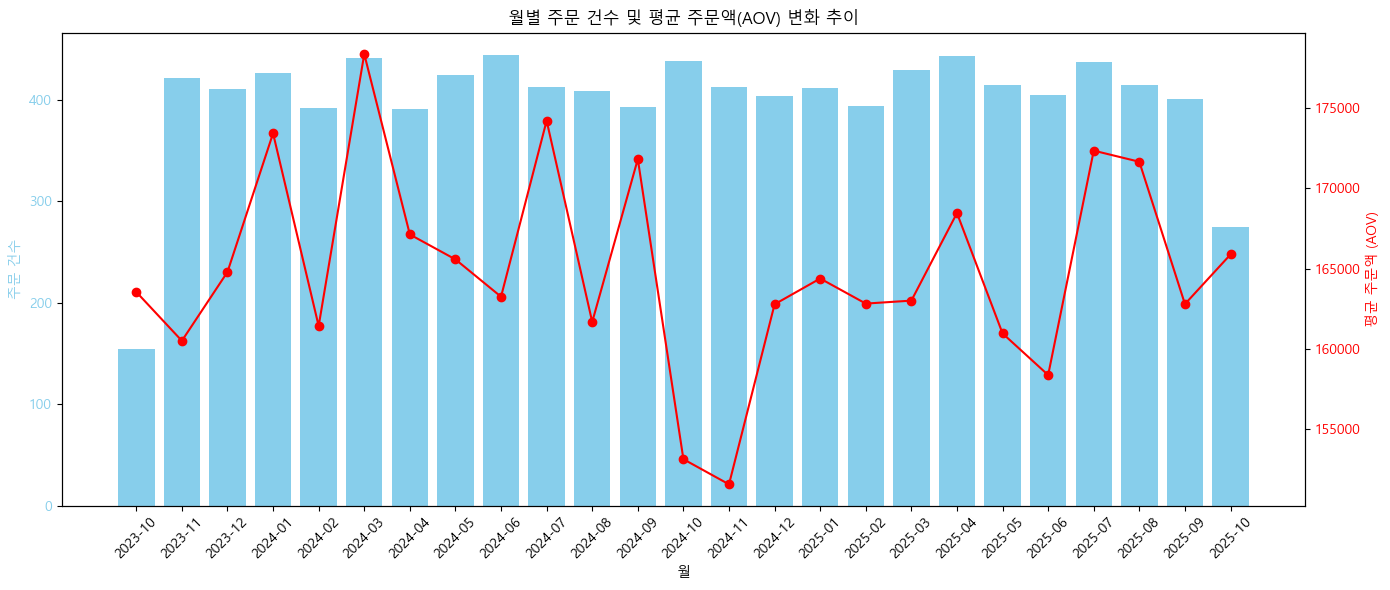

In [7]:
cols = ['order_date','total_sales']

df_data2 = df[cols].copy()

df_data2['year_month'] = df_data2['order_date'].dt.to_period('M')

# 월별 집계
monthly_stats = df_data2.groupby('year_month').agg({
    'order_date': 'count',  # 주문 건수
    'total_sales': 'sum'     # 총 매출
}).reset_index()

monthly_stats.columns = ['year_month', 'order_count', 'total_sales']

# AOV(Average Order Value) 계산
monthly_stats['aov'] = monthly_stats['total_sales'] / monthly_stats['order_count']

# year_month를 문자열로 변환 (시각화를 위해)
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)

# 이중 축 차트 생성
fig, ax1 = plt.subplots(figsize=(14, 6))

# 첫 번째 축: 주문 건수
color1 = 'skyblue'
ax1.set_xlabel('월')
ax1.set_ylabel('주문 건수', color=color1)
bar = ax1.bar(monthly_stats['year_month'], monthly_stats['order_count'], 
                 color=color1, label='주문 건수')
ax1.tick_params(axis='y', labelcolor=color1)

# 두 번째 축: AOV
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('평균 주문액 (AOV)', color=color2)
line2 = ax2.plot(monthly_stats['year_month'], monthly_stats['aov'], 
                 color=color2, marker = 'o', label='AOV')
ax2.tick_params(axis='y', labelcolor=color2)

# 제목 및 레이아웃
plt.title('월별 주문 건수 및 평균 주문액(AOV) 변화 추이')

# X축 레이블 회전
ax1.set_xticks(monthly_stats['year_month'])
ax1.set_xticklabels(monthly_stats['year_month'], rotation=45)

plt.tight_layout()
plt.show()


In [8]:
# 문제 3: 주문 취소율(pending 상태)이 월별로 어떻게 변화하는지 추적하세요.
# 시각화: 라인 플롯

#비즈니스 목적: 특정 기같에 주문 취소가 급증하는지 파악하고, 해당 시점의 이벤트나 시스템 변경 등의 원인을 분석하여 문제를 개선합니다.

월별 주문 취소율(%)
            pending  total_orders  cancel_rate
year_month                                    
2023-10           3           154     1.948052
2023-11          24           421     5.700713
2023-12          27           411     6.569343
2024-01          27           426     6.338028
2024-02          20           392     5.102041
2024-03          20           441     4.535147
2024-04          14           391     3.580563
2024-05          16           424     3.773585
2024-06          24           444     5.405405
2024-07          11           413     2.663438
2024-08          20           409     4.889976
2024-09          24           393     6.106870
2024-10          11           438     2.511416
2024-11          26           413     6.295400
2024-12          24           404     5.940594
2025-01          19           412     4.611650
2025-02          17           394     4.314721
2025-03          21           429     4.895105
2025-04          18           443     4.063205


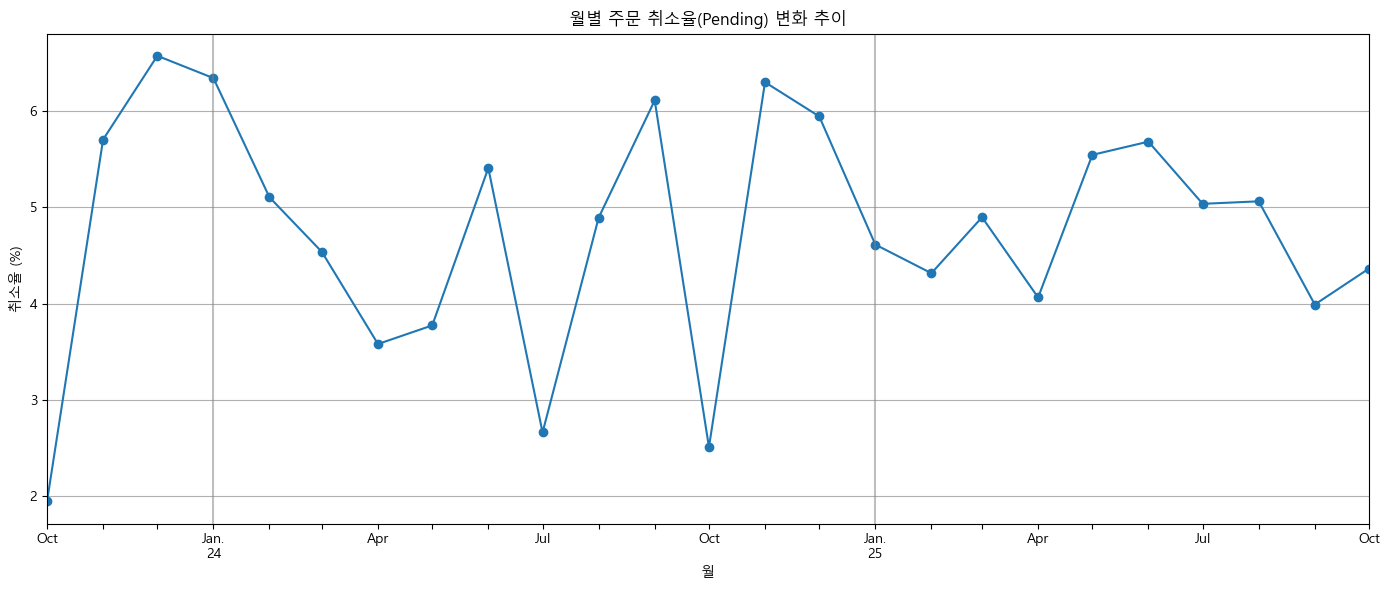

In [9]:
cols = ['order_date','payment_status']

df_data3 = df[cols].copy()

df_data3['year_month'] = df_data3['order_date'].dt.to_period('M')

# payment_status가 pending인지 확인하는 컬럼 추가
df_data3['is_pending'] = (df_data3['payment_status'] == 'Pending').astype(int)

# 월별 집계
monthly_cancel = df_data3.groupby('year_month').agg({
    'is_pending': 'sum',       # pending 주문 건수
    'payment_status': 'count'  # 전체 주문 건수
}).reset_index()

monthly_cancel.columns = ['year_month', 'pending', 'total_orders']

# 취소율(pending 비율) 계산
monthly_cancel['cancel_rate'] = (monthly_cancel['pending'] / monthly_cancel['total_orders']) * 100

monthly_cancel.set_index('year_month', inplace=True)

print('월별 주문 취소율(%)')
print(monthly_cancel)

monthly_cancel.index = monthly_cancel.index.to_timestamp()

# 라인 플롯 생성
fig, ax = plt.subplots(figsize=(14, 6))

# 취소율 라인 플롯
ax.plot(monthly_cancel.index,monthly_cancel['cancel_rate'], marker='o',
        label='주문 취소율 (Pending)')

# 스타일링
ax.set_xlabel('월')
ax.set_ylabel('취소율 (%)')
ax.set_title('월별 주문 취소율(Pending) 변화 추이', 
)


xticks = monthly_cancel.index
xlabels = []
for ym in xticks:
    month = ym.month
    if month==1:
        xlabels.append(ym.strftime('%b.\n%y'))
    elif month in [4,7,10]:
        xlabels.append(ym.strftime('%b'))
    else:
        xlabels.append('')
# X축 레이블 회전
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

# X축 범위 설정
ax.set_xlim(min(xticks),max(xticks))
ax.set_ylim()
# 그리드 추가
ax.grid(axis='y', linestyle='-')
for i, ym in enumerate(xticks):
    if ym.month == 1:
        plt.axvline(x=xticks[i],linestyle='-',color='gray', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# 문제 4: 첫 구매 고객의 주문과 재구매 고객의 고객의 주문 간 평균 주문액(AOV)를 비교하세요.
# 비즈니스 목적: 고객의 충성도가 높아질수록 구매 규모도 커지는지 확인하고, 재구매 고객 대상의 VIP 마케팅 효과를 측정합니다.

첫 구매 vs 재구매 고객 평균 주문액(AOV)
                 total_sales
purchase_type               
재구매            164512.284644
첫 구매           167092.311558


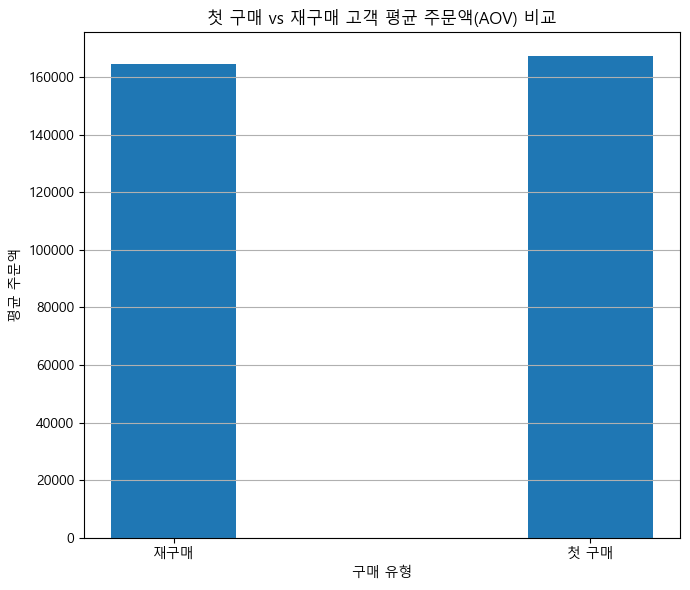

In [11]:
cols = ['customer_id','order_date','total_sales']

df_data4 = df[cols].copy()

# 각 고객의 첫 구매 날짜 찾기
first_purchase = df_data4.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']

# 원본 데이터에 첫 구매 날짜 병합
df_data4 = df_data4.merge(first_purchase, on='customer_id', how='left')

# 첫 구매 여부 판단
df_data4['is_first_purchase'] = (df_data4['order_date'] == df_data4['first_purchase_date'])
df_data4['purchase_type'] = df_data4['is_first_purchase'].map({
    True: '첫 구매',
    False: '재구매'
})

# 고객 유형별 AOV 계산
aov_comparison = df_data4.groupby('purchase_type').agg({
    'total_sales': 'mean'
}).reset_index()
aov_comparison.set_index('purchase_type', inplace=True)
print('첫 구매 vs 재구매 고객 평균 주문액(AOV)')
print(aov_comparison)

fig, ax = plt.subplots(figsize=(7, 6))

ax.bar(aov_comparison.index, aov_comparison['total_sales'], width= 0.3)

ax.set_title('첫 구매 vs 재구매 고객 평균 주문액(AOV) 비교')
ax.set_xlabel('구매 유형')
ax.set_ylabel('평균 주문액')

ax.grid(axis='y', linestyle='-')

plt.tight_layout()
plt.show()

In [12]:
# 문제 5: 주문량이 가장 많았던 상위 10개 해당 요일을 찾으세요.
# 비즈니스 목적: 특별히 주문이 몰렸던 날짜를 파악하고, 해당 날짜의 이벤트, 프로모션, 사회적 이슈 등을 분석하여 향후 마케팅 전략에 반영합니다.

In [13]:
cols = ['order_date','quantity']

df_data5 = df[cols].copy()

df_data5['date'] = df_data5['order_date'].dt.to_period('D')

order_cnt = df_data5.groupby('date').agg(order_count=('order_date','count')).sort_values('order_count', ascending=False).reset_index()

order_cnt['day'] = order_cnt['date'].dt.dayofweek

week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
order_cnt['day_of_week'] = order_cnt['day'].map(dict(enumerate(week)))

print(order_cnt[['date','order_count','day_of_week']].head(10))

         date  order_count day_of_week
0  2023-12-04           29      Monday
1  2025-04-13           26      Sunday
2  2025-02-07           25      Friday
3  2025-02-18           25     Tuesday
4  2025-10-11           24    Saturday
5  2025-01-24           23      Friday
6  2024-09-07           23    Saturday
7  2025-06-12           23    Thursday
8  2025-06-08           22      Sunday
9  2025-07-04           22      Friday


In [14]:
# 문제 6: 첫 구매 후 30일 이내에 재구매한 고객의 비율(단기 리텐션)을 계산하세요.
# 비즈니스 목적: 신규 고객이 얼마나 빠르게 우리 서비스에 안착하는지 측정하는 핵심 지표로, 온보딩 프로세스의 성공 여부를 판단하는 데 사용합니다.

In [41]:
cols = ['customer_id','order_date']

df_data6 = df[cols].copy()
# 각 고객별로 구매 날짜를 정렬
df_data6 = df_data6.sort_values(['customer_id', 'order_date'])

# 각 고객의 첫 구매 날짜 계산
first_purchase = df_data6.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_order_date']

# 원본 데이터와 첫 구매 날짜 병합
df_data6 = df_data6.merge(first_purchase, on='customer_id')

# 첫 구매가 아닌 주문만 필터링 (재구매)
df_repurchase = df_data6[df_data6['order_date'] > df_data6['first_order_date']].copy()

# 첫 구매 후 경과 일수 계산
df_repurchase['days_since_first'] = (df_repurchase['order_date'] - df_repurchase['first_order_date']).dt.days

# 30일 이내 재구매한 고객 찾기
customers_repurchased_within_30days = df_repurchase[df_repurchase['days_since_first'] <= 30]['customer_id'].unique()

# 전체 고객 수
total_customers = df_data6['customer_id'].nunique()

# 30일 이내 재구매한 고객 수
repurchase_customers = len(customers_repurchased_within_30days)

# 단기 리텐션 비율 계산
short_term_retention_rate = (repurchase_customers / total_customers) * 100

print(f'첫 구매 후 30일 이내 재구매 고객 비율: {short_term_retention_rate:0.2f}%')

첫 구매 후 30일 이내 재구매 고객 비율: 20.10%


In [16]:
# 문제 7: 주문량이 상위10%인 날짜들은 주로 어떤 요일에 분포하는지 분석하세요
# 비즈니스 목적: '대박 나는 날'의 공통적인 요일패턴을 파악하고,
# 해당 요일에 더 많은 마케팅 리소스를 집중하거나 서버 증설을 준비하는 등의 전략을 수립합니다


요일별 분포:
weekday_name
Friday       16.216216
Saturday     16.216216
Monday       15.315315
Sunday       15.315315
Thursday     12.612613
Wednesday    12.612613
Tuesday      11.711712
Name: count, dtype: float64


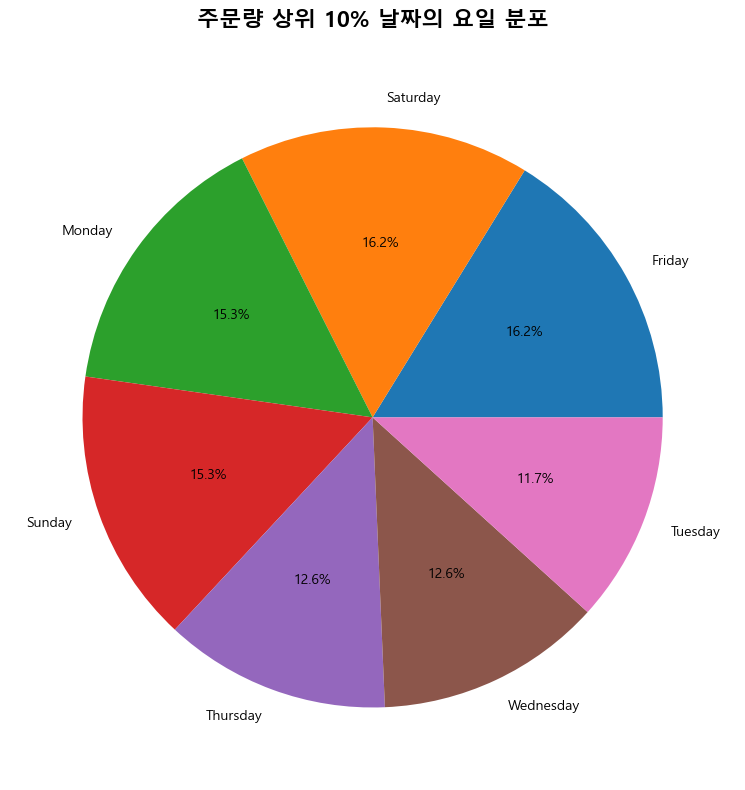

In [44]:
cols = ['customer_id','order_date']

df_data7 = df[cols].copy()

# 날짜별 주문량 계산
df_data7['date'] = df_data7['order_date'].dt.to_period('D')

daily_orders = df_data7.groupby('date').agg(order_count=('order_date','count')).sort_values('order_count', ascending=False).reset_index()

# 상위 10% 기준값 계산
top_10_threshold = daily_orders['order_count'].quantile(0.90)

# 상위 10% 날짜 필터링
top_10_dates = daily_orders[daily_orders['order_count'] >= top_10_threshold].copy()

# 요일 추출 (0=월요일, 6=일요일)
top_10_dates['weekday'] = top_10_dates['date'].dt.dayofweek

# 요일 이름 매핑 (한글)
weekday_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
top_10_dates['weekday_name'] = top_10_dates['weekday'].map(weekday_names)

# 요일별 빈도 계산
weekday_distribution = top_10_dates['weekday_name'].value_counts()/len(top_10_dates)

# 결과 출력
print("\n요일별 분포:")
print(weekday_distribution*100)

# 파이차트 시각화
plt.figure(figsize=(10, 8))

plt.pie(weekday_distribution.values, 
        labels=weekday_distribution.index,
        autopct='%1.1f%%',
        startangle=0
        )

plt.title('주문량 상위 10% 날짜의 요일 분포', fontsize=16, fontweight='bold', pad=20)
# plt.axis('equal')
plt.tight_layout()
plt.show()